# E-commerce Customer Churn Prediction

### Business Problem

The e-commerce company is facing a growing challenge of customer churn, where a significant portion of users discontinue their engagement and purchasing activities over time. Using the available dataset, which includes customer demographics, behavioral patterns, and transaction history, the objective is to develop a data-driven approach to identify customers who are at risk of churning. By analyzing key factors such as purchase frequency, login activity, cart abandonment rates, and time since last interaction, the business aims to uncover the primary drivers influencing customer attrition. These insights will enable the organization to implement targeted retention strategies, optimize customer engagement, and ultimately enhance overall customer lifetime value and profitability.

#### Import numpy , pandas and Seaborn 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


### Load data set (csv file)

In [2]:
df=pd.read_csv(r"C:\Users\shrut\Downloads\ecommerce_customer_churn_dataset.csv")

In [3]:
df.head() # display first 5 columns of dataframe

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
df.info() # describe information about the dataset 

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [5]:
df.isna().sum() # Sum of missing values for each column

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

#### This dataset contain null values

### Data cleaning :cleaning null values

<Axes: >

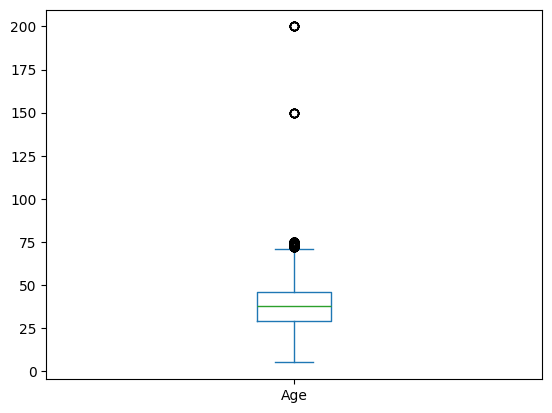

In [6]:
df['Age'].plot(kind='box')  # To find outliers of Age column

#### Age has outliers so fill null values with median

In [7]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [8]:
df.isna().sum() #In age column null values filled using median

Age                                 0
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

<Axes: >

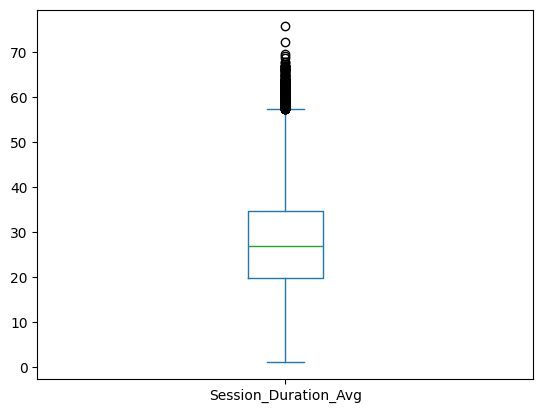

In [9]:
df['Session_Duration_Avg'].plot(kind='box')

In [10]:
df['Session_Duration_Avg']=df['Session_Duration_Avg'].fillna(df['Session_Duration_Avg'].median())

In [11]:
df.isna().sum()

Age                                 0
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg                0
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

<Axes: >

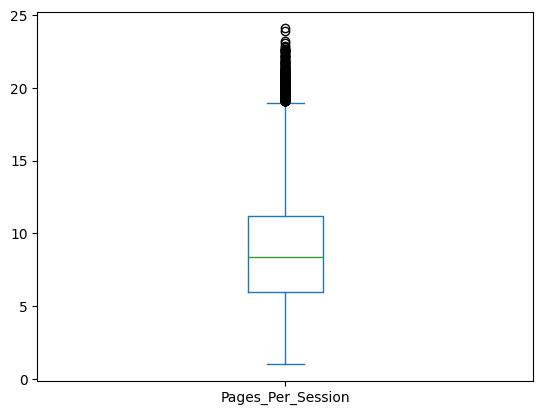

In [12]:
df['Pages_Per_Session'].plot(kind='box') # this column contains outlier so fill null values with median

In [13]:
df['Pages_Per_Session']=df['Pages_Per_Session'].fillna(df['Pages_Per_Session'].median())

<Axes: >

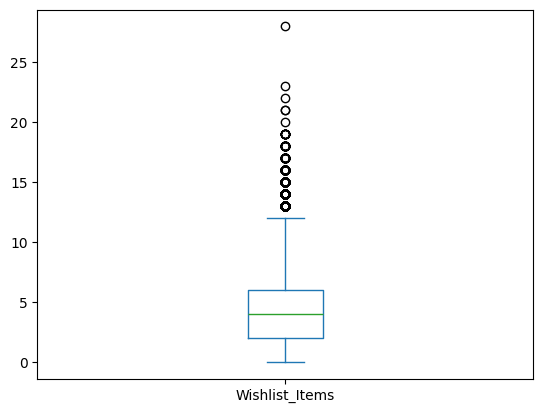

In [14]:
df['Wishlist_Items'].plot(kind='box')

In [15]:
df['Wishlist_Items']=df['Wishlist_Items'].fillna(df['Wishlist_Items'].median())

In [16]:
df['Days_Since_Last_Purchase'].value_counts()

Days_Since_Last_Purchase
1.0      1480
2.0      1453
3.0      1361
4.0      1304
6.0      1286
         ... 
245.0       1
190.0       1
255.0       1
287.0       1
238.0       1
Name: count, Length: 235, dtype: int64

In [17]:
df['Days_Since_Last_Purchase']=df['Days_Since_Last_Purchase'].bfill().ffill()

In [18]:
df.isna().sum()

Age                                 0
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg                0
Pages_Per_Session                   0
Cart_Abandonment_Rate               0
Wishlist_Items                      0
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase            0
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

<Axes: >

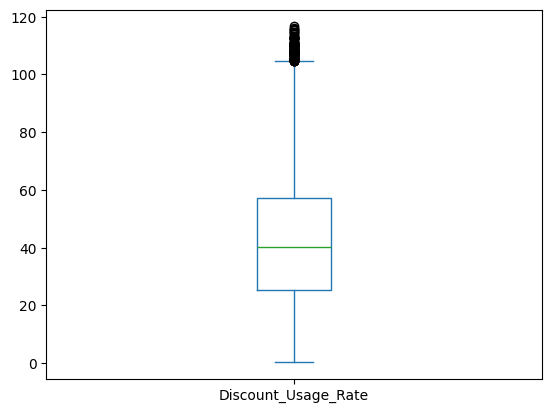

In [19]:
df['Discount_Usage_Rate'].plot(kind='box')

In [20]:
df['Discount_Usage_Rate']=df['Discount_Usage_Rate'].fillna(df['Discount_Usage_Rate'].median())

<Axes: >

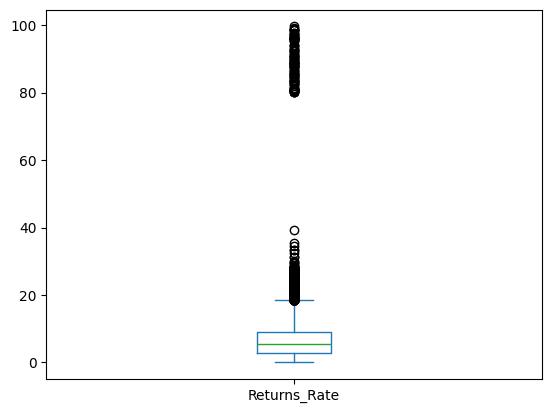

In [21]:
df['Returns_Rate'].plot(kind='box')

In [22]:
df['Returns_Rate']=df['Returns_Rate'].fillna(df['Returns_Rate'].median())

In [23]:
df['Email_Open_Rate']=df['Email_Open_Rate'].fillna(df['Email_Open_Rate'].median())

In [24]:
df['Customer_Service_Calls']=df['Customer_Service_Calls'].fillna(df['Customer_Service_Calls'].median())

In [25]:
df['Product_Reviews_Written']=df['Product_Reviews_Written'].fillna(df['Product_Reviews_Written'].median())

In [26]:
df['Social_Media_Engagement_Score']=df['Social_Media_Engagement_Score'].fillna(df['Social_Media_Engagement_Score'].median())

<Axes: >

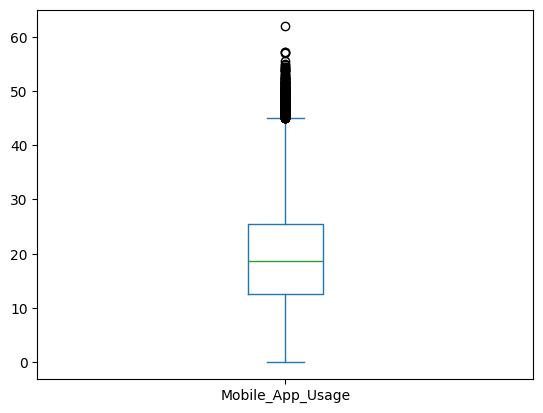

In [27]:
df['Mobile_App_Usage'].plot(kind='box')

In [28]:
df['Mobile_App_Usage']=df['Mobile_App_Usage'].fillna(df['Mobile_App_Usage'].median())

In [29]:
df['Payment_Method_Diversity']=df['Payment_Method_Diversity'].fillna(df['Payment_Method_Diversity'].median())

In [30]:
df['Credit_Balance']=df['Credit_Balance'].fillna(df['Credit_Balance'].median())

In [31]:
df.isna().sum() # missing values of all columns are filled 

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

### Handling Inconsistent data

#####  Check values names and its count  of each column using value_counts

In [32]:
df['City'].value_counts()

City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Montreal       1247
Toronto        1209
Calgary        1204
Ottawa         1182
Vancouver      1181
Cologne        1033
Hamburg        1026
Berlin         1013
Munich          960
Frankfurt       893
Lyon            830
Sydney          828
Adelaide        817
Perth           817
Toulouse        815
Melbourne       805
Nice            799
Brisbane        794
Marseille       793
Paris           776
Chennai         736
Bangalore       698
Mumbai          694
Delhi           693
Hyderabad       691
Tokyo           537
Nagoya          514
Kyoto           507
Osaka           496
Yokohama        494
Name: count, dtype: int64

In [33]:
df['Gender'].value_counts()

Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

In [34]:
df['Country'].value_counts()

Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

In [35]:
df['Signup_Quarter'].value_counts()

Signup_Quarter
Q3    12558
Q2    12521
Q4    12468
Q1    12453
Name: count, dtype: int64

In [36]:
# There is no inconsistency in data 

### Handling Outliers

In [37]:
num_cols=df.select_dtypes(include='number').columns
num_cols

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned'],
      dtype='str')

In [38]:
from feature_engine.outliers import Winsorizer

In [39]:
capper=Winsorizer(capping_method='iqr',fold=1.5,tail='both')

In [40]:
df=capper.fit_transform(df)

<Axes: >

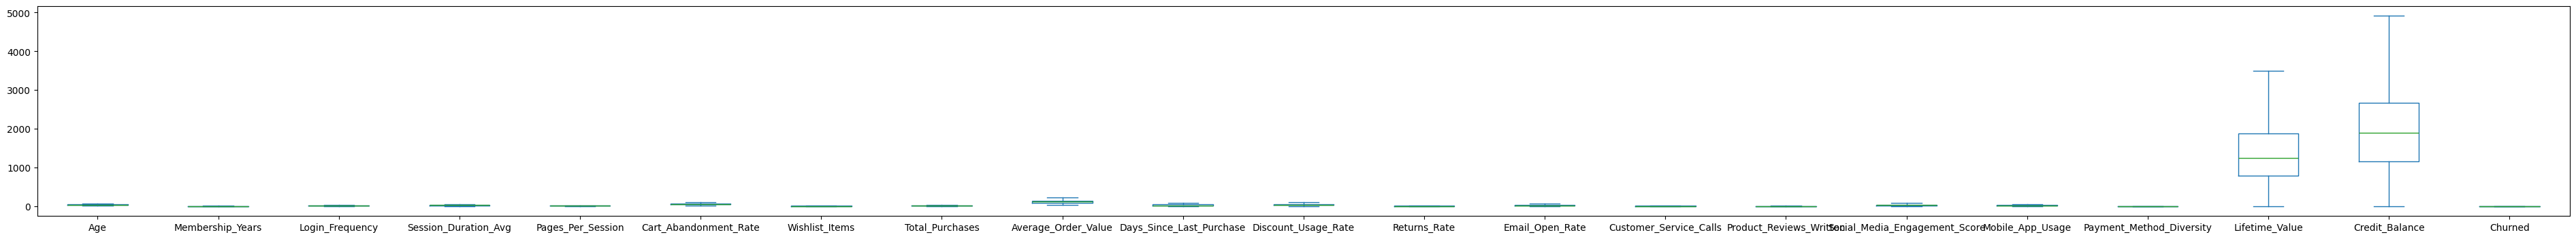

In [41]:
df.plot(kind='box',figsize=(48,4)) 

####  Now there are no outliers in data.Outliers are handled using Winsorizer method

### Data Manipulation questions

In [42]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='str')

#### 1.Filter customers with Membership_Years > 5.

In [44]:
df[df['Membership_Years']>5]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
12,40.0,Female,USA,Phoenix,7.1,10.0,19.2,7.0,69.1,6.0,...,9.6,4.0,2.0,17.7,18.6,4.0,1229.94000,2446.0,0,Q1
19,21.0,Female,Australia,Adelaide,5.6,9.0,27.5,8.8,52.1,4.0,...,19.7,7.0,5.0,28.2,25.6,1.0,1274.70000,3107.0,0,Q3
30,30.0,Male,Germany,Cologne,5.4,8.0,27.0,9.0,61.0,3.0,...,4.6,9.0,5.0,15.4,18.6,3.0,1585.98000,240.0,0,Q1
32,37.0,Male,Germany,Munich,7.5,29.0,48.9,15.9,27.8,12.0,...,33.6,1.0,8.5,59.0,39.6,4.5,3367.15000,2544.0,1,Q3
48,42.0,Male,Australia,Brisbane,6.0,0.0,30.2,10.1,64.3,4.0,...,27.1,8.0,2.0,13.6,20.2,2.0,907.62000,4038.0,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49960,38.0,Male,Australia,Brisbane,5.1,8.0,21.5,4.3,57.6,4.0,...,27.2,6.0,1.0,3.6,18.6,2.0,1440.38000,1011.0,0,Q1
49963,28.0,Female,USA,Chicago,5.1,17.0,39.3,16.8,30.3,6.0,...,41.6,5.0,5.0,49.6,18.6,2.0,2554.88000,3268.0,0,Q4
49987,37.0,Female,USA,New York,5.4,12.0,31.1,5.7,80.7,3.0,...,7.3,4.0,3.0,19.0,23.1,3.0,1131.42000,0.0,0,Q3
49988,63.0,Female,Canada,Ottawa,6.6,14.0,32.0,10.2,55.8,4.0,...,20.6,2.0,2.0,11.1,25.3,1.0,3500.27375,3888.0,0,Q3


#### 2.Customers with Average_Order_Value > 100 AND Returns_Rate >15.

In [45]:
df[(df['Average_Order_Value']>100) & (df['Returns_Rate']>15)]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
18,27.0,Female,India,Bangalore,2.0,0.0,20.3,9.8,59.8,2.0,...,12.5,4.0,0.0,3.4,17.5,3.0,1096.88,54.0,0,Q2
25,39.0,Female,UK,Glasgow,3.9,14.0,19.6,11.6,65.3,7.0,...,23.3,8.0,6.0,43.5,25.4,3.0,1846.48,2511.0,0,Q1
57,38.0,Female,Germany,Munich,2.1,10.0,39.6,8.9,38.9,5.0,...,32.0,4.0,1.0,51.3,16.0,2.0,2779.71,2268.0,0,Q1
66,37.0,Male,USA,Phoenix,3.8,6.0,32.8,10.5,51.2,7.0,...,8.8,7.0,4.0,48.4,10.9,1.0,1333.02,1.0,0,Q3
87,41.0,Male,USA,Chicago,3.4,23.0,44.6,14.2,46.8,5.0,...,39.2,4.0,1.0,35.2,27.8,1.0,1862.75,2442.0,0,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49913,56.0,Female,USA,Chicago,1.9,27.0,50.5,18.2,24.4,6.0,...,31.2,2.0,3.0,68.9,39.9,2.0,2950.33,1896.0,1,Q4
49975,24.0,Female,Australia,Brisbane,0.1,15.0,40.5,7.9,39.8,3.0,...,43.6,2.0,2.0,45.9,31.2,2.0,2118.59,4757.0,1,Q1
49980,38.0,Male,Canada,Montreal,4.6,5.0,14.2,1.0,53.5,1.0,...,7.8,6.0,0.0,22.0,9.5,2.0,442.25,293.0,0,Q2
49981,43.0,Female,India,Bangalore,0.9,21.0,42.4,11.9,41.0,3.0,...,36.7,4.0,2.0,48.4,29.3,2.0,1735.98,1738.0,0,Q1


### 3.Customers with Credit_Balance < 5000 AND Churned = 1

In [46]:
df[(df['Credit_Balance']<5000) & (df['Churned']==1)]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
5,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
10,32.0,Male,UK,Glasgow,0.9,0.0,12.3,2.9,73.5,0.0,...,0.0,11.0,2.0,17.0,8.0,1.0,599.41,498.0,1,Q2
11,32.0,Female,Germany,Munich,0.6,11.0,12.1,5.6,77.2,0.0,...,4.0,7.0,1.0,0.0,17.7,2.0,335.92,1369.0,1,Q3
13,18.0,Female,USA,Phoenix,3.1,13.0,26.1,8.9,47.7,2.0,...,19.0,8.0,4.0,27.6,21.5,3.0,1083.91,2772.0,1,Q3
21,35.0,Male,USA,New York,4.7,6.0,14.4,6.5,80.9,4.0,...,19.9,8.0,1.0,3.3,2.9,1.0,644.58,1896.0,1,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49975,24.0,Female,Australia,Brisbane,0.1,15.0,40.5,7.9,39.8,3.0,...,43.6,2.0,2.0,45.9,31.2,2.0,2118.59,4757.0,1,Q1
49986,43.0,Male,USA,New York,3.6,16.0,24.5,8.2,76.8,5.0,...,1.0,7.0,2.0,19.2,13.2,2.0,1604.56,3847.0,1,Q3
49990,40.0,Male,UK,Glasgow,4.0,15.0,12.7,8.1,68.6,2.0,...,15.0,10.0,1.0,17.7,18.6,1.0,2196.96,928.0,1,Q4
49992,33.0,Male,France,Nice,4.5,6.0,26.8,6.9,67.1,2.0,...,7.1,8.0,3.0,3.2,12.9,4.5,917.83,1298.0,1,Q4


#### 4.Retrieve customers with Pages_Per_Session > 12 AND Login_Frequency > 15.

In [47]:
df.query("Pages_Per_Session>12  and Login_Frequency>15")

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
6,56.0,Male,Germany,Berlin,1.9,24.0,46.4,13.9,36.20,5.0,...,35.5,4.0,6.0,68.8,41.7,4.5,3003.57,2657.0,0,Q1
15,31.0,Female,USA,New York,1.4,24.0,50.8,18.0,44.00,5.0,...,45.0,4.0,5.0,78.8,26.5,1.0,1692.54,2564.0,0,Q3
20,55.0,Female,India,Bangalore,1.2,24.0,50.3,16.0,25.20,9.0,...,58.5,1.0,5.0,76.7,37.8,1.0,3063.29,4561.0,0,Q1
23,20.0,Female,USA,Los Angeles,2.7,27.0,49.7,14.4,29.30,11.0,...,43.0,2.0,8.5,65.3,37.3,2.0,3014.34,1725.0,1,Q3
24,31.0,Female,Australia,Sydney,3.3,18.0,40.1,12.8,45.50,7.0,...,38.0,5.0,8.0,68.3,41.7,2.0,1935.29,2465.0,0,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49935,33.0,Male,USA,Houston,3.4,20.0,38.2,14.8,46.20,6.0,...,33.1,4.0,7.0,27.6,22.4,4.0,1863.48,2824.0,0,Q3
49949,34.0,Male,Germany,Hamburg,4.4,21.0,53.1,12.7,32.60,4.0,...,33.3,0.0,8.5,78.8,32.9,2.0,1849.40,2525.0,1,Q3
49963,28.0,Female,USA,Chicago,5.1,17.0,39.3,16.8,30.30,6.0,...,41.6,5.0,5.0,49.6,18.6,2.0,2554.88,3268.0,0,Q4
49966,45.0,Male,Germany,Munich,1.2,18.0,29.9,12.4,40.00,7.0,...,33.4,4.0,2.0,21.5,24.5,1.0,3227.53,2267.0,0,Q3


#### 5.Filter customers from City == 'Mumbai' OR City == 'Delhi' using query.

In [48]:
df.query("City=='Mumbai' or City=='Delhi'")

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.10,9.0,...,37.9,1.0,8.5,78.8,41.7,4.0,3041.29,4914.0,0,Q4
51,33.0,Male,India,Mumbai,1.4,0.0,33.6,6.9,64.00,4.0,...,8.0,4.0,2.0,2.0,18.6,1.0,692.85,1165.0,0,Q2
182,25.0,Male,India,Mumbai,2.5,20.0,26.8,10.3,61.80,8.0,...,24.3,4.0,5.0,35.5,21.5,2.0,1057.99,1896.0,0,Q3
208,44.0,Female,India,Mumbai,4.8,18.0,26.8,11.1,65.00,4.0,...,28.1,10.0,4.0,27.6,17.0,1.0,2488.85,1919.0,1,Q2
272,51.0,Female,India,Delhi,1.5,8.0,10.2,4.9,76.90,2.0,...,0.0,7.0,2.0,0.7,14.6,2.0,685.12,0.0,1,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49870,32.0,Female,India,Mumbai,2.8,7.0,38.7,10.1,46.20,2.0,...,32.5,3.0,4.0,27.6,28.7,1.0,1411.35,2211.0,0,Q1
49895,29.0,Female,India,Mumbai,2.0,3.0,26.8,1.5,79.80,0.0,...,0.0,9.0,0.0,10.6,8.3,3.0,695.95,0.0,1,Q2
49909,37.0,Male,India,Mumbai,5.0,26.0,49.6,16.4,29.70,12.0,...,30.4,4.0,8.5,78.8,29.6,4.0,1952.75,3154.0,0,Q4
49939,55.0,Female,India,Delhi,3.8,2.0,18.4,4.2,78.10,2.0,...,8.6,6.0,0.0,0.0,6.7,2.0,1456.32,304.0,0,Q4


#### 6.Get customers where Signup_Quarter == 'Q1' AND Churned = 1.

In [49]:
df.query("Signup_Quarter=='Q1' and Churned==1")

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
5,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
55,49.0,Female,USA,Houston,1.8,0.0,13.2,5.8,58.6,1.0,...,11.9,9.0,2.0,0.9,6.6,4.0,2134.96,0.0,1,Q1
56,27.0,Male,UK,Manchester,1.6,9.0,10.5,7.0,72.8,1.0,...,0.0,9.0,2.0,6.3,5.3,1.0,826.32,206.0,1,Q1
137,34.0,Female,UK,Manchester,0.2,10.0,12.6,2.3,79.8,1.0,...,13.9,9.0,0.0,0.8,15.4,2.0,976.87,1896.0,1,Q1
155,29.0,Male,Australia,Sydney,0.6,6.0,34.4,8.4,42.6,8.0,...,31.8,6.0,2.0,25.5,24.3,1.0,2506.18,2549.0,1,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49873,18.0,Male,Canada,Calgary,3.4,13.0,25.7,6.8,77.5,5.0,...,17.1,6.0,2.0,39.1,26.0,2.0,2566.44,4581.0,1,Q1
49917,62.0,Female,USA,Houston,2.0,0.0,26.8,3.8,72.6,4.0,...,11.6,9.0,2.0,9.4,12.1,2.0,540.74,1896.0,1,Q1
49918,55.0,Male,USA,Houston,2.7,7.0,26.8,7.3,81.4,0.0,...,13.2,10.0,0.0,18.5,11.2,4.0,544.27,2287.0,1,Q1
49970,45.0,Male,UK,London,1.8,25.0,54.0,9.1,35.9,4.0,...,39.6,6.0,5.0,62.3,29.4,3.0,1926.58,1880.0,1,Q1


#### 7.Find high-risk churn customers: Membership_Years < 2, Cart_Abandonment_Rate > 0.6 ,Login_Frequency < 10

In [50]:
df.query("Membership_Years<2 and Cart_Abandonment_Rate>0.6 and Login_Frequency<10")

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
10,32.0,Male,UK,Glasgow,0.9,0.0,12.3,2.9,73.5,0.0,...,0.0,11.0,2.0,17.0,8.0,1.0,599.41,498.0,1,Q2
16,25.0,Female,Canada,Ottawa,0.9,4.0,12.4,3.7,68.5,1.0,...,0.0,9.0,1.0,0.0,15.5,1.0,503.26,1048.0,0,Q3
17,41.0,Male,USA,Los Angeles,0.7,5.0,19.5,5.3,68.0,2.0,...,1.2,4.0,2.0,0.0,13.4,1.0,1356.93,1924.0,0,Q4
34,47.0,Male,Germany,Munich,0.7,1.0,12.4,8.4,59.2,0.0,...,23.0,2.0,0.0,0.0,9.4,2.0,257.65,1736.0,0,Q1
42,36.0,Male,USA,Chicago,1.4,0.0,33.0,5.1,75.1,4.0,...,11.6,6.0,1.0,23.9,19.9,3.0,1133.62,1416.0,0,Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49962,51.0,Other,USA,Phoenix,0.8,3.0,21.0,6.8,83.5,0.0,...,0.0,5.0,1.0,27.6,5.2,4.5,780.36,1896.0,1,Q3
49967,38.0,Female,USA,Phoenix,0.6,8.0,33.1,10.5,49.4,3.0,...,40.2,2.0,8.0,43.4,25.2,4.0,2674.01,2464.0,0,Q2
49971,41.0,Female,Germany,Berlin,0.4,3.0,11.5,5.9,81.4,0.0,...,0.0,5.0,2.0,0.0,9.2,1.0,816.98,212.0,0,Q4
49974,20.0,Female,UK,Leeds,0.3,0.0,11.8,3.9,87.7,1.0,...,19.7,7.0,0.0,2.4,7.1,1.0,236.47,359.0,1,Q3


#### 8.Select the last 10 rows of the dataset using .iloc.

In [51]:
df.iloc[-10:]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
49990,40.0,Male,UK,Glasgow,4.0,15.0,12.7,8.1,68.6,2.0,...,15.0,10.0,1.0,17.7,18.6,1.0,2196.96,928.0,1,Q4
49991,29.0,Male,USA,Chicago,4.9,12.0,40.1,10.2,40.7,9.0,...,12.6,3.0,4.0,51.3,25.6,3.0,1257.02,0.0,0,Q4
49992,33.0,Male,France,Nice,4.5,6.0,26.8,6.9,67.1,2.0,...,7.1,8.0,3.0,3.2,12.9,4.5,917.83,1298.0,1,Q4
49993,56.0,Female,Canada,Calgary,2.0,14.0,35.5,8.9,52.9,12.0,...,40.5,5.0,2.0,35.4,18.3,3.0,1581.65,2732.0,0,Q3
49994,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,3.0,...,17.4,6.0,5.0,15.4,14.6,2.0,813.11,3565.0,1,Q2
49995,38.0,Female,USA,Los Angeles,7.9,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,18.6,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,27.6,14.1,3.0,1286.11,2634.0,0,Q2
49999,56.0,Male,UK,Leeds,2.2,2.0,18.2,8.4,46.0,0.0,...,0.0,7.0,0.0,0.0,4.2,1.0,1072.61,612.0,0,Q3


#### 9.Extract only Age, Gender, Country columns using column positions.

In [52]:
df.loc[:,['Age','Gender','Country']]

,Age,Gender,Country
0,43.0,Male,France
1,36.0,Male,UK
2,45.0,Female,Canada
3,56.0,Female,USA
4,35.0,Male,India
...,...,...,...
49995,38.0,Female,USA
49996,37.0,Male,USA
49997,44.0,Female,USA
49998,41.0,Female,USA


#### 10.Use .loc to filter churned customers + .iloc for first 3 columns

In [54]:
df.loc[df["Churned"] == 1].iloc[:, :3]

,Age,Gender,Country
5,35.0,Male,Japan
10,32.0,Male,UK
11,32.0,Female,Germany
13,18.0,Female,USA
21,35.0,Male,USA
...,...,...,...
49975,24.0,Female,Australia
49986,43.0,Male,USA
49990,40.0,Male,UK
49992,33.0,Male,France


#### 11. Rows 20 to 40 and columns 0 to 6 using .iloc

In [55]:
df.iloc[20:41,0:7]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg
20,55.0,Female,India,Bangalore,1.2,24.0,50.3
21,35.0,Male,USA,New York,4.7,6.0,14.4
22,38.0,Male,Japan,Yokohama,2.7,30.0,45.1
23,20.0,Female,USA,Los Angeles,2.7,27.0,49.7
24,31.0,Female,Australia,Sydney,3.3,18.0,40.1
25,39.0,Female,UK,Glasgow,3.9,14.0,19.6
26,38.0,Female,Japan,Nagoya,1.3,17.0,18.9
27,42.0,Male,USA,Phoenix,0.4,17.0,34.6
28,30.0,Male,Germany,Frankfurt,1.4,16.0,38.2
29,34.0,Male,Japan,Yokohama,4.4,12.0,42.1


#### 12.Get the value of Age for the first row using .iat.

In [56]:
df.iat[0,0]

np.float64(43.0)

#### 13.Access Country of the last row using .iat.

In [57]:
df.iat[-1,2]

'UK'

#### 14.Get the Lifetime_Value of the 15th customer

In [58]:
df.at[14,'Lifetime_Value']

np.float64(1618.51)

#### 15. Get Customer_Service_Calls for customer index 30

In [59]:
df.at[30,'Customer_Service_Calls']

np.float64(9.0)

In [60]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,78.8,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,8.5,78.8,41.7,4.0,3041.29,4914.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,7.9,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,18.6,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,27.6,14.1,3.0,1286.11,2634.0,0,Q2


# Data Visualization

### Univariate analysis using pandas plotting

#### Which age group has the highest number of users plot a graph for this data?

<Axes: ylabel='Frequency'>

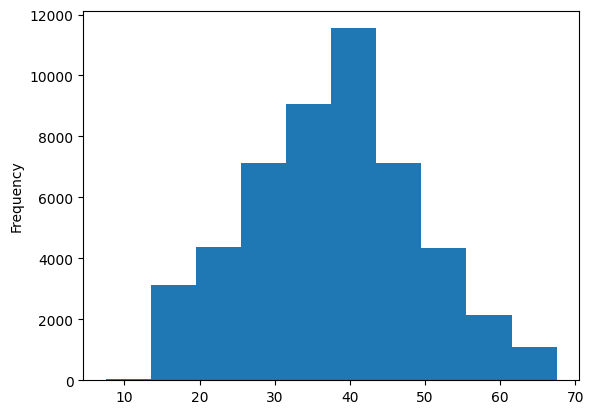

In [61]:
df['Age'].plot(kind='hist') 

1. The distribution is mostly concentrated between 38-43  years, indicating this platform is used mainly by young to middle-aged customers.

#### What is the average login frequency of users?

<Axes: ylabel='Frequency'>

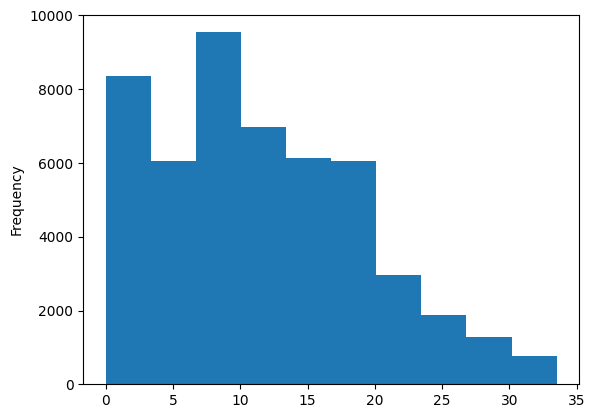

In [62]:
df['Login_Frequency'].plot(kind='hist')

Most values are usually concentrated in the lower to mid range, indicating that majority of users log in occasionally rather than very frequently.

#### What is the average number of reviews per customer?

<Axes: ylabel='Density'>

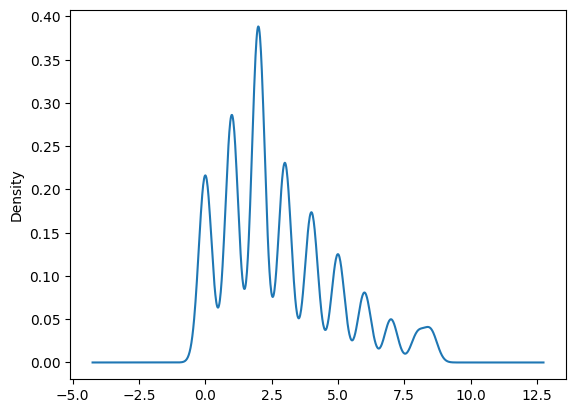

In [63]:
df['Product_Reviews_Written'].plot(kind='kde',x='Product_Reviews_Written')

Most people gave product review between 3.8-4.0.


In [64]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='str')

#### What is the most common purchase range among customers?

<Axes: ylabel='Density'>

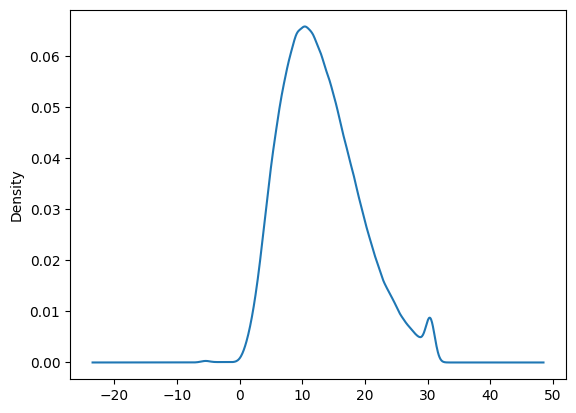

In [65]:
df['Total_Purchases'].plot(kind='kde')

1. The curve shows a peak around 10–15 purchases, meaning most customers make moderate number of purchases.
2. The distribution is right-skewed (tail toward higher values), indicating:
 A small group of customers makes very high purchases (20–30+)
 Majority are regular/moderate buyers
3. There is a slight bump near higher values (~30), which may represent a small segment of highly loyal customers.
4. Very low density at extremes → very few customers with very low or extremely high purchases.

#### Which countries contribute the largest customer base?

<Axes: >

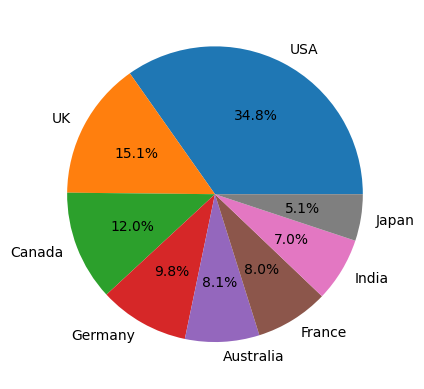

In [66]:
df['Country'].value_counts().plot(kind='pie',autopct='%1.1f%%')

1. The majority of customers are from the USA.
2. The UK accounts for approximately 15% of customers.
3. Japan has the lowest number of customers, at around 5%.

#### What percentage of customers belong to each gender category?

<Axes: >

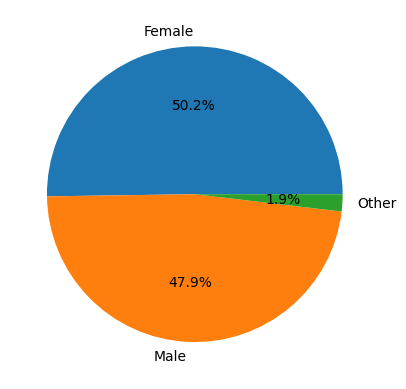

In [67]:
df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')

1. Females constitute 50.2% of the customers, forming the majority.
2. Males account for 47.9%, which is slightly lower but still comparable.
3. Other genders represent 1.9%, indicating a very small segment.

#### What is the most common range of wishlist items?

<Axes: ylabel='Frequency'>

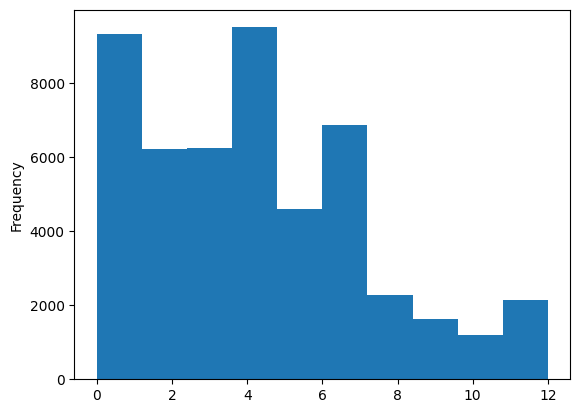

In [68]:
df['Wishlist_Items'].plot(kind='hist')

1. The distribution shows that most customers have low to moderate wishlist items (around 0–6).
2. The frequency gradually decreases as the number of wishlist items increases, indicating fewer users with high counts.
3. The data is right-skewed, meaning: Majority of users add few items. A small group adds many items (8–12).
4. Presence of higher values (10–12) suggests highly interested or engaged users.

#### What are the two most common order value ranges?

<Axes: ylabel='Density'>

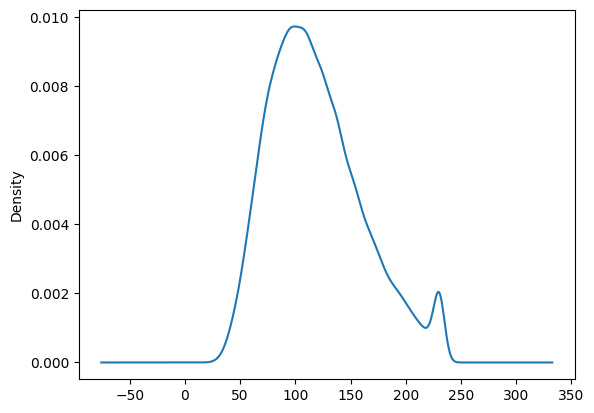

In [69]:
df['Average_Order_Value'].plot(kind='kde')

1. The distribution shows a major peak around 125, indicating that most customers place orders in this price range (primary spending group).
2. There is a smaller secondary peak around 225–250, suggesting a second segment of high-value customers.

#### Which quarter has the highest number of signups?

<Axes: >

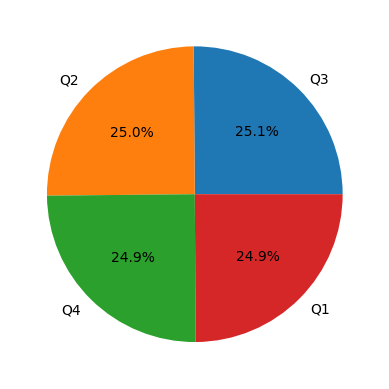

In [70]:
df['Signup_Quarter'].value_counts().plot(kind='pie',autopct='%1.1f%%')

1. All quarters have approximately 25% of customers each, indicating an even distribution of signups throughout the year.
2. This suggests that customer acquisition is consistent and not seasonal.

#### Does high discount usage increase or decrease churn?

<Axes: ylabel='Density'>

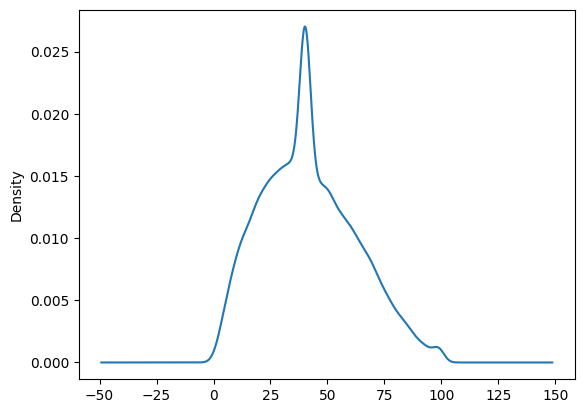

In [71]:
df['Discount_Usage_Rate'].plot(kind='kde')

1. The distribution shows a peak around 40–50%, meaning most customers use discounts moderately.
2. The curve is slightly right-skewed, indicating:. Majority of users use discounts occasionally to moderately. Fewer users rely heavily on discounts (70–100%)
3. The sharp peak suggests many customers have similar discount behavior.
4. The tail toward higher values shows a small segment of highly discount-dependent users.

### Bivariate analysis using Matplotlib

In [72]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,78.8,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,8.5,78.8,41.7,4.0,3041.29,4914.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,7.9,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,18.6,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,27.6,14.1,3.0,1286.11,2634.0,0,Q2


In [73]:
import matplotlib.pyplot as plt

#### Is there a relationship between Age and Membership_Years?

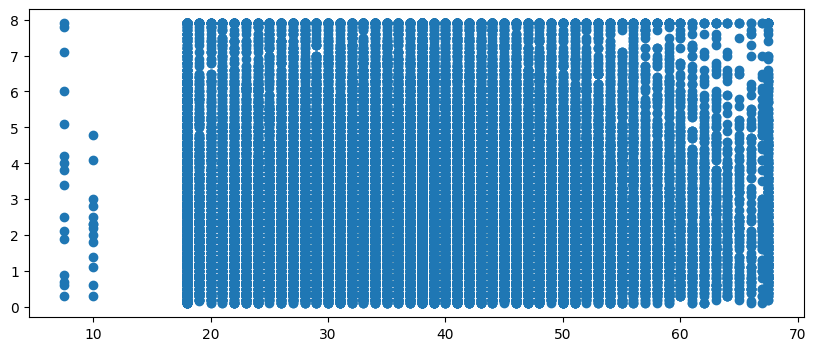

In [74]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,x='Age',y='Membership_Years')

1.People from age 18-68 have membership_years upto 8 .These age limit people will use more.

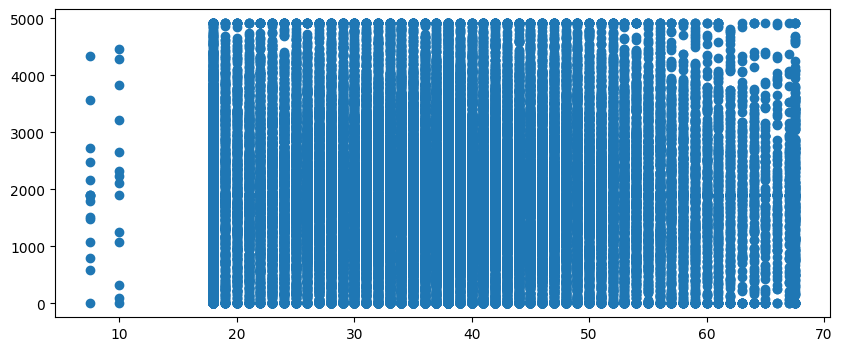

In [75]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,x='Age',y='Credit_Balance')

 Customers between the ages of 18 and 68 exhibit credit balances ranging from 0 to 5000, whereas very few customers aged 10 years or below have credit balances ranging from 0 to 4000.

In [76]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='str')

#### Wishlist Items Vs Total Purchases

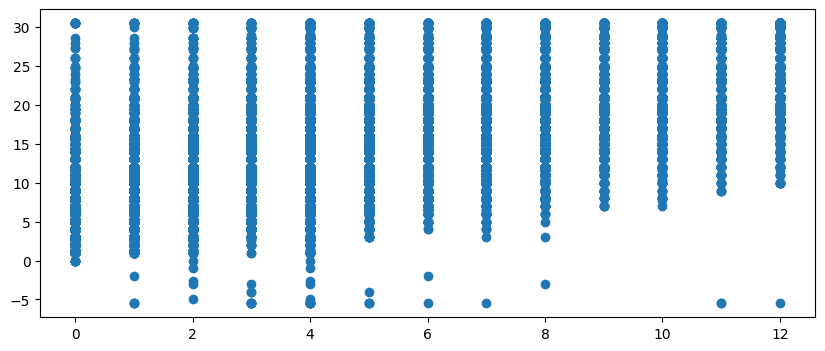

In [77]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,x='Wishlist_Items',y='Total_Purchases')

Most customers have low to moderate wishlist items (0–12) and moderate purchases (around 0-30).
The scatter is widely spread, indicating a weak to moderate positive relationship.
There is no strong linear trend, meaning: Adding items to wishlist does not always convert into purchases

#### Social_Media_Engagement Vs Session Durration Average

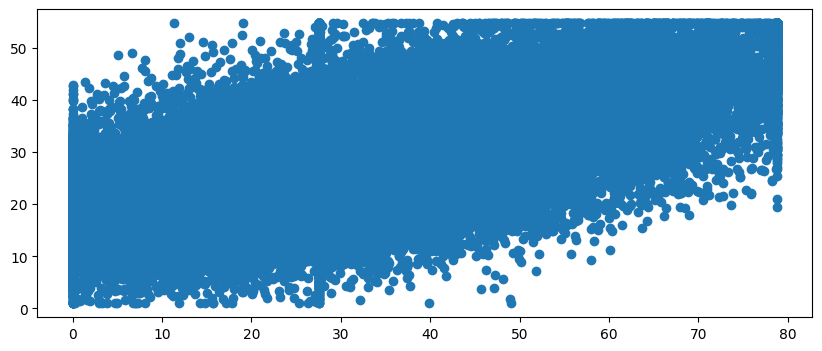

In [78]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,x='Social_Media_Engagement_Score',y='Session_Duration_Avg')

1. The scatter plot shows the relationship between user engagement on social media and time spent per session on the platform.
2. If the points show an upward trend:
 Users with higher social media engagement tend to spend more time per session.
 Indicates highly engaged and active users

#### Total Purchases Vs Return Rate

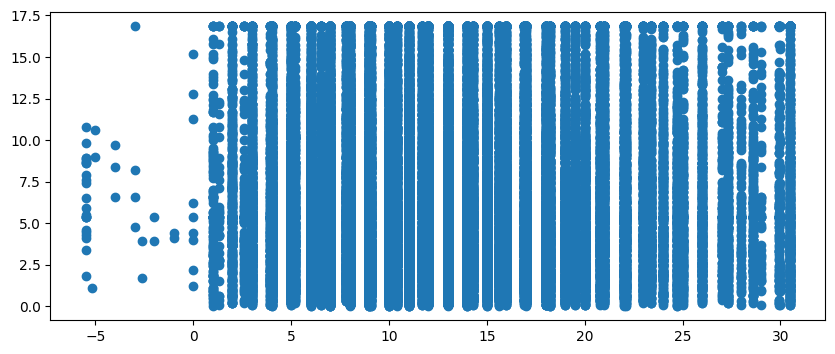

In [79]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,x='Total_Purchases',y='Returns_Rate')

The plot shows no clear correlation between purchase volume and return rates, as data points are distributed uniformly across the vertical axis regardless of total purchases.

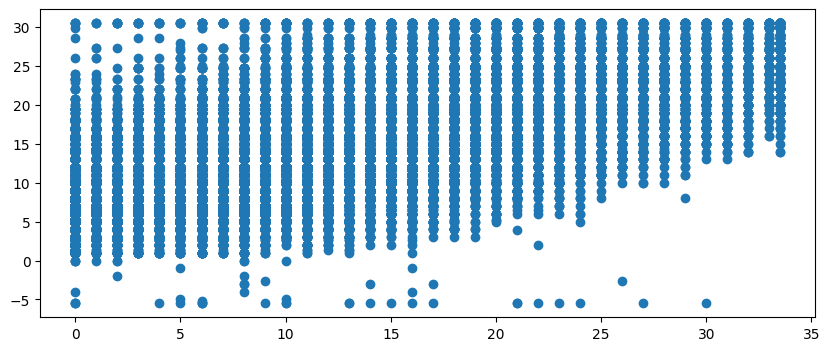

In [80]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,y='Total_Purchases',x='Login_Frequency')

The scatter plot shows the relationship between Login_Frequency and Total_Purchases.
1. There is a moderate positive relationship: as login frequency increases, total purchases generally increase.
2. The points are widely spread at each login level, indicating that users with the same login frequency can have very different purchase behaviors.

#### Can login frequency alone predict customer purchasing behavior effectively?

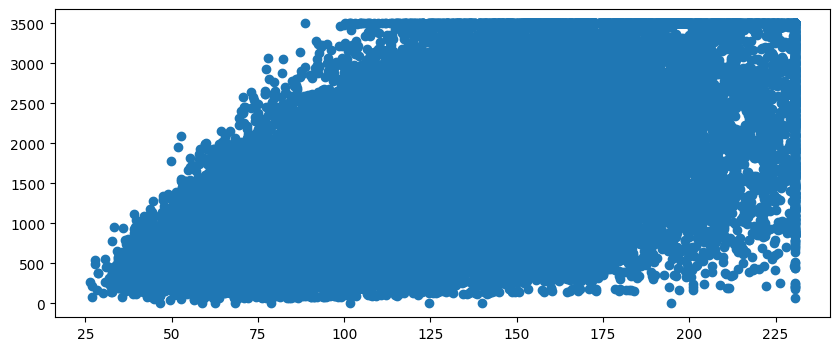

In [81]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,x='Average_Order_Value',y='Lifetime_Value')

#### How does discount usage influence customer purchasing behavior?

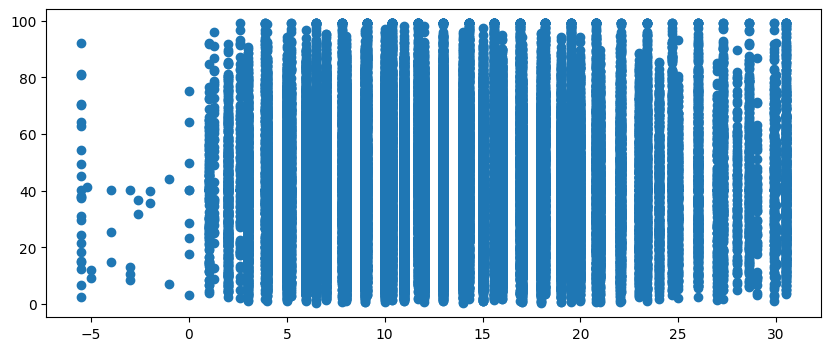

In [82]:
plt.figure(figsize=(10,4))
plt.scatter(data=df,y='Discount_Usage_Rate',x='Total_Purchases')

There is no significant correlation between discount rates and total purchases; customers appear to buy at the same frequency whether a high discount is available or not.

### Multivariate analysis using seaborn plotting


#### How does login frequency differ between churned and non-churned users?

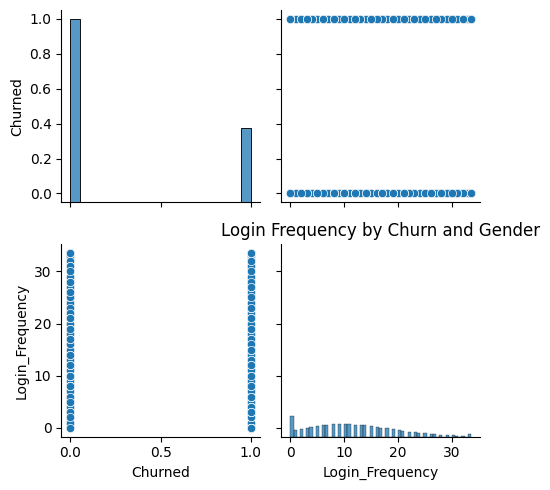

In [83]:
sns.pairplot(df[['Churned','Login_Frequency','Gender']])
plt.title("Login Frequency by Churn and Gender")
plt.tight_layout()

In [84]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,78.8,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,8.5,78.8,41.7,4.0,3041.29,4914.0,0,Q4


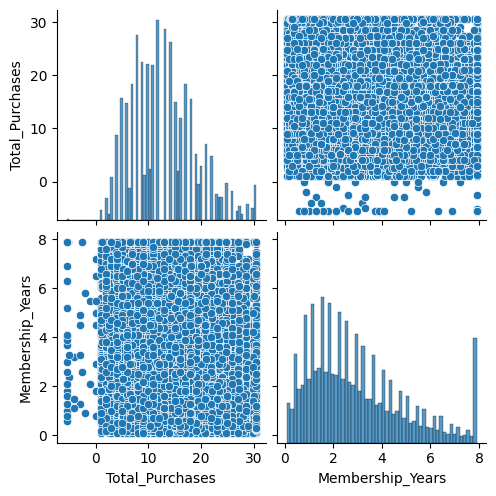

In [92]:
sns.pairplot(df[['Total_Purchases','Membership_Years','Country']]) # pairplot is combination of histogram and Scatterplot

<Axes: xlabel='Total_Purchases', ylabel='Average_Order_Value'>

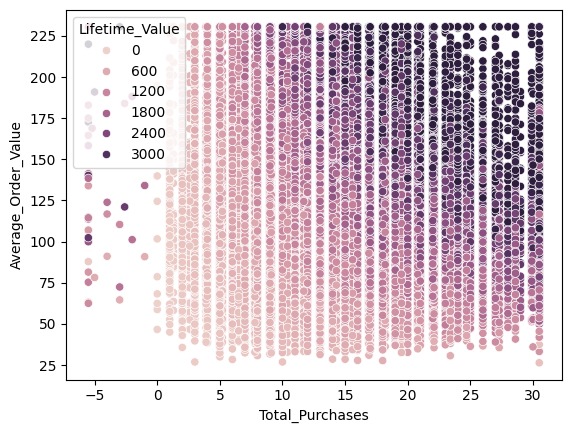

In [86]:
sns.scatterplot(x='Total_Purchases',
                y='Average_Order_Value',
                hue='Lifetime_Value', data=df)

There’s no strong relationship between Total_Purchases (x-axis) and Average_Order_Value (y-axis), as values are widely scattered at each purchase level. Customers with more purchases tend to show higher Lifetime_Value (darker colors), suggesting LTV is driven more by frequency than order size. Average order value remains quite variable regardless of how often customers buy.

#### Is there any relationship between age and membership duration?

<Axes: xlabel='Age', ylabel='Membership_Years'>

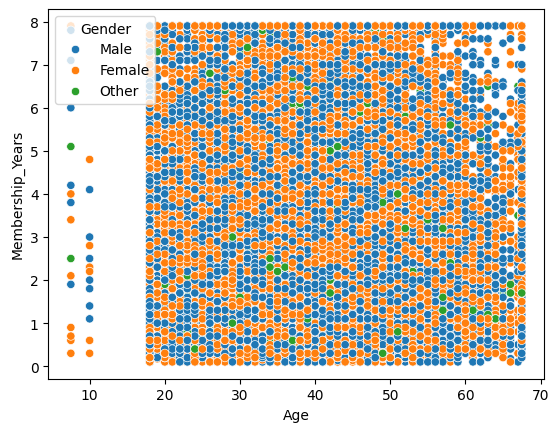

In [87]:
sns.scatterplot(data=df,x='Age',y='Membership_Years',hue='Gender')

The plot shows no significant relationship between age, membership duration, and gender, indicating that customer loyalty is independent of demographic factors.

#### Is there a relationship between login frequency and total purchases?

<Axes: xlabel='Login_Frequency', ylabel='Total_Purchases'>

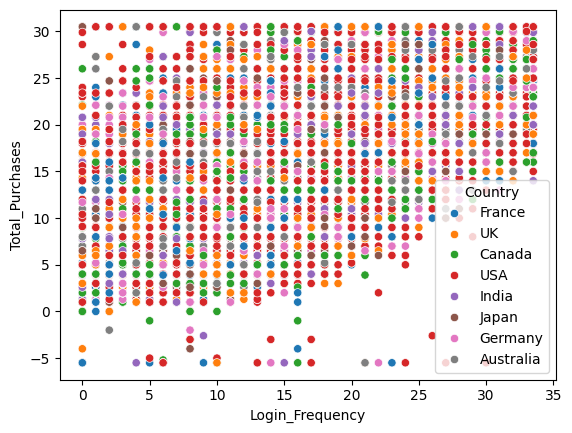

In [88]:
sns.scatterplot(x='Login_Frequency', y='Total_Purchases',
                hue='Country', data=df)

The plot shows a moderate positive relationship between login frequency and total purchases, indicating that higher user engagement leads to increased purchasing behavior, with consistent pattern

#### Does social media engagement influence spending behavior?

<Axes: xlabel='Product_Reviews_Written', ylabel='Social_Media_Engagement_Score'>

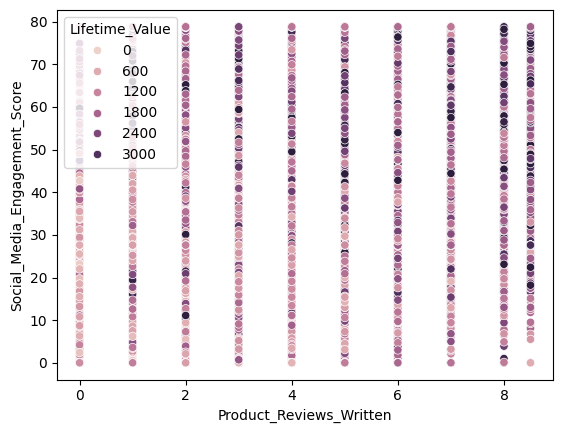

In [89]:
sns.scatterplot(x='Product_Reviews_Written',
                y='Social_Media_Engagement_Score',
                hue='Lifetime_Value', data=df)

Customers with higher product review activity and social media engagement tend to have greater lifetime value, indicating that engagement is a key driver of customer profitability.

#### Does social media engagement influence spending behavior?

<Axes: xlabel='Pages_Per_Session', ylabel='Session_Duration_Avg'>

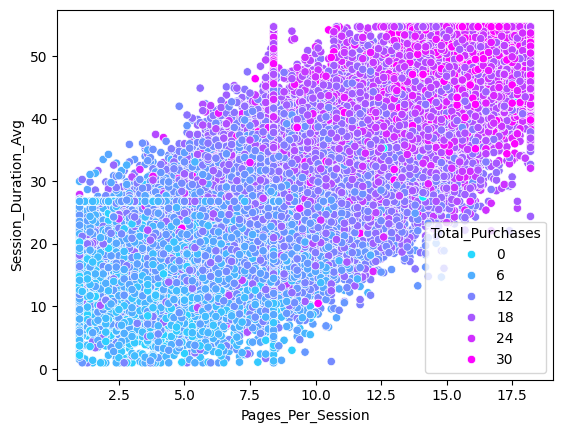

In [90]:
sns.scatterplot(data=df,x='Pages_Per_Session',y='Session_Duration_Avg',hue='Total_Purchases',palette='cool')

Customers with higher product review activity and social media engagement tend to have greater lifetime value, indicating that engagement is a key driver of customer profitability.

#### Does an increase in service calls indicate customer dissatisfaction?

<Axes: xlabel='Customer_Service_Calls', ylabel='Cart_Abandonment_Rate'>

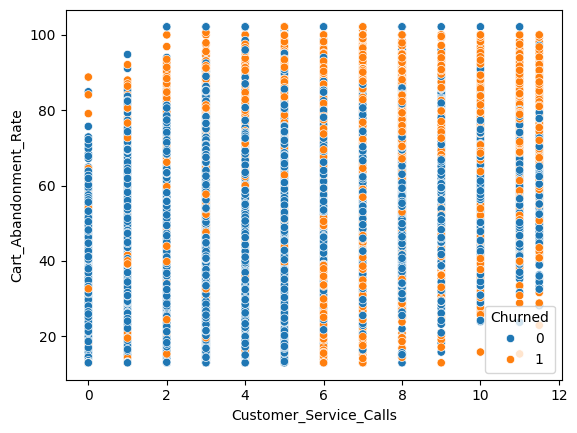

In [91]:
sns.scatterplot(x='Customer_Service_Calls',
                y='Cart_Abandonment_Rate',
                hue='Churned', data=df)

The plot shows that customers with higher service calls and cart abandonment rates are more likely to churn, indicating dissatisfaction as a key driver of customer loss.

### Insights

1. Age, Gender, and Membership
There is no strong relationship between age, gender, and membership years.
Customer loyalty is independent of demographic factors.

2. Login Frequency vs Total Purchases
A moderate positive relationship exists between login frequency and total purchases.
Users who log in more frequently tend to purchase more.

3. Engagement Behavior
Higher engagement (login frequency, session duration, pages per session)
leads to higher purchasing activity.

4. Total Purchases vs Average Order Value
There is no strong relationship between purchase frequency and order value.
Customers with higher purchases tend to generate higher lifetime value.

5. Discount Usage
Discount usage does not significantly impact total purchases.
Customers purchase regardless of discount levels.

6. Cart Abandonment & Customer Service Calls
Customers with more service calls and higher cart abandonment rates
are more likely to churn, indicating dissatisfaction.

7. Churn Drivers
Key factors affecting churn:
- Low login frequency
- High cart abandonment rate
- More customer service calls
- Low purchase activity

8. Signup Quarter
Customers are evenly distributed across all quarters,
indicating no seasonal trend in user acquisition.

9. Missing Values
Some columns contain missing values (e.g., Social_Media_Engagement_Score,
Credit_Balance, Mobile_App_Usage), which require proper handling.

10. High-Risk Customers
Customers with:
- Low engagement
- High abandonment rate
- Frequent service calls
are more likely to churn.

### Conclusion

The analysis of the e-commerce dataset highlights key factors contributing to customer churn, such as low engagement and reduced purchasing activity. By leveraging behavioral and transactional data, businesses can effectively predict at-risk customers. These insights enable targeted retention strategies and improved customer experience. Ultimately, this leads to higher customer loyalty and increased business profitability.